# 10 - The Questions a Reviewer Would Ask

A senior colleague read this repository the way a hiring manager would, and
wrote down the questions it left open. Some were about choices that were
made once and never tested. Some were about what the numbers mean for the
business. Some were about production. This notebook answers each one, with a
measurement where a measurement is possible and with a reason where it is
not.

Every measurement here uses the last backtest window - training up to
19 June 2015, the six weeks after it hidden - and one seed. That is the
screening protocol of notebook 07: enough to answer a question, not enough
to change the model. The whole notebook runs in about a quarter of an hour.

In [1]:
import sys
import time
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.forecaster import Forecaster, evaluate
from src.features import FeatureBuilder, build_closure_calendar
from src.model import SalesModel, DEFAULT_PARAMS
from src.segments import StoreSegmenter
from src.metrics import rmspe

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
pl.Config.set_tbl_rows(20)

loader = DataLoader(PROJECT_ROOT / "data")
df = loader.load()
calendar = loader.load(drop_closed=False)
CUT = date(2015, 6, 19)
before = df.filter(pl.col("Date") <= CUT)
before_calendar = calendar.filter(pl.col("Date") <= CUT)
hidden = calendar.filter(pl.col("Date") > CUT)
hidden_open = df.filter(pl.col("Date") > CUT)
timings = {}
print(f"Training up to {CUT}: {before.height:,} rows. Hidden: {hidden_open.height:,} open days.")

Training up to 2015-06-19: 804,110 rows. Hidden: 40,282 open days.


## 1. What does the error mean for the business?

RMSPE is a number for comparing models. The people who order stock think in
units and in direction: how many units off, and too many or too few. The
model of check 1 in notebook 09 is trained again here, with an 80 percent
interval this time, and its misses on the hidden window are read the way a
planner would read them.

In [2]:
started = time.perf_counter()
base = Forecaster().fit(before, before_calendar)
scored = base.predict(hidden, interval=0.8).filter(pl.col("Open") == 1)
timings["base model"] = time.perf_counter() - started
score = rmspe(scored["Sales"], scored["prediction"])

miss = scored.with_columns(
    (pl.col("prediction") - pl.col("Sales")).alias("units"),
    ((pl.col("prediction") - pl.col("Sales")) / pl.col("Sales")).alias("share"))
abs_units = miss["units"].abs()
print(f"RMSPE on the hidden window: {score:.4f}")
print(f"A typical open day sells {scored['Sales'].median():,.0f} units.")
print(f"The median miss is {abs_units.median():,.0f} units, "
      f"{100 * miss['share'].abs().median():.1f} percent of the day's sales.")
print(f"Half of the days are within {abs_units.quantile(0.5):,.0f} units, "
      f"nine in ten within {abs_units.quantile(0.9):,.0f}.")
print(f"Too high on {100 * (miss['units'] > 0).mean():.0f} percent of the days, "
      f"too low on {100 * (miss['units'] < 0).mean():.0f} percent.")
print(f"Over the six weeks the forecast sums to "
      f"{100 * (scored['prediction'].sum() / scored['Sales'].sum() - 1):+.1f} percent "
      f"of the real total.")

RMSPE on the hidden window: 0.1083
A typical open day sells 6,384 units.
The median miss is 398 units, 6.3 percent of the day's sales.
Half of the days are within 398 units, nine in ten within 1,172.
Too high on 48 percent of the days, too low on 52 percent.
Over the six weeks the forecast sums to -0.7 percent of the real total.


**A typical day is 6,400 units, a typical miss is 400.** Half of the days
land within 400 units of the real sales, nine in ten within 1,200. The
forecast is too high on 48 percent of the days and too low on 52, and over
the six weeks it adds up to 0.7 percent below the real total: it does not
lean to one side.

That last point is where the business question starts. A miss of 400 units
upward is stock on a shelf for a few more days; a miss of 400 units downward
is an empty shelf and a customer who leaves. Those two do not cost the same,
and the model does not know which one is worse, because nobody told it. It
forecasts the middle. If the company said that a missing unit costs three
times a spare one, the right forecast would sit above the middle, at the
level where the expected cost is smallest - a quantile, not a median. That
is a one-line change in the objective, and it is the first thing to ask the
planners for.

## 2. Does the error grow with the horizon?

A six-week forecast is not one forecast. The first day is one day ahead,
the last is forty-two days ahead. If the error grows quickly with the
distance, the plan should trust the first weeks and hold the last ones
loosely. The hidden window is cut into weeks of distance from the last
training day.

In [3]:
by_horizon = (scored.with_columns(
    (((pl.col("Date") - pl.lit(CUT)).dt.total_days() - 1) // 7 + 1).alias("week_ahead"))
    .group_by("week_ahead").agg(
        pl.len().alias("rows"),
        (((pl.col("Sales") - pl.col("prediction")) / pl.col("Sales")) ** 2).mean().sqrt()
        .round(4).alias("rmspe"))
    .sort("week_ahead"))
print(by_horizon)

shape: (6, 3)
┌────────────┬──────┬────────┐
│ week_ahead ┆ rows ┆ rmspe  │
│ ---        ┆ ---  ┆ ---    │
│ i64        ┆ u32  ┆ f64    │
╞════════════╪══════╪════════╡
│ 1          ┆ 6717 ┆ 0.0944 │
│ 2          ┆ 6720 ┆ 0.1117 │
│ 3          ┆ 6717 ┆ 0.1195 │
│ 4          ┆ 6708 ┆ 0.0979 │
│ 5          ┆ 6710 ┆ 0.0984 │
│ 6          ┆ 6710 ┆ 0.1246 │
└────────────┴──────┴────────┘


**The error does not grow with the horizon.** Week one scores 0.094 and
week six 0.125, but weeks four and five sit at 0.098, below week two. The
error follows the calendar, not the distance: the hard weeks are the ones
with the start of the school holidays, not the far ones.

The reason is a design choice made in notebook 01. The model has no memory
of the last few days - no "sales yesterday", no "sales last week" - because
those are not known six weeks ahead. Every feature it uses is known in
advance, so day forty-two is as easy as day one. The price is the other
half of the same fact: a shock that started yesterday, a road closed or a
competitor opened, is invisible to the model until it shows up in the store
statistics at the next retraining. A second model for the first week, with
lags, would catch it; the six-week model would stay for the plan.

Why six weeks at all? Because the competition asked for six weeks; the
test file itself runs 48 days. A company would not start from a number.
It would start from the decision the forecast serves, and each decision
has its own horizon: the lead time of an order is one or two weeks, a
staff roster is published two to four weeks ahead, a budget looks at
months. The backtest would then follow the rhythm of that decision - a
new cut every Monday, a window as long as the decision needs, many
windows instead of four - and the error would be reported by week ahead,
as it is above. Two models is the likely end: a short one with lags for
the orders, and this one for the plan.

## 3. Why gradient boosting, and not a time-series model?

Two answers: a measurement and a reason.

The measurement is a second baseline, of the kind a time-series person would
reach for first: **the same weekday one year ago**, which carries the season
and the weekly shape, with the median of the past as a fallback where the
store has no such day. The baseline of notebook 02, the median for each
store, weekday and promotion state, is shown next to it.

In [4]:
median = (before.group_by(["Store", "DayOfWeek", "Promo"])
          .agg(pl.col("Sales").median().alias("median_baseline")))
year_ago = before.select(["Store",
                          (pl.col("Date") + timedelta(days=364)).alias("Date"),
                          pl.col("Sales").alias("year_ago")])
naive = (scored.join(median, on=["Store", "DayOfWeek", "Promo"], how="left")
         .join(year_ago, on=["Store", "Date"], how="left")
         .with_columns(pl.col("median_baseline").fill_null(before["Sales"].median())))
no_year_ago = naive["year_ago"].is_null().sum()
naive = naive.with_columns(pl.col("year_ago").fill_null(pl.col("median_baseline")))
print(f"{'same weekday, one year ago':<30} {rmspe(naive['Sales'], naive['year_ago']):.4f}"
      f"   ({no_year_ago:,} rows without a year-ago day, filled with the median)")
print(f"{'median of the past (nb 02)':<30} {rmspe(naive['Sales'], naive['median_baseline']):.4f}")
print(f"{'the model':<30} {score:.4f}")

same weekday, one year ago     0.1608   (5,196 rows without a year-ago day, filled with the median)
median of the past (nb 02)     0.1449
the model                      0.1083


**The same weekday one year ago scores 0.161** - worse than the median of
the past at 0.145, and far from the model at 0.108. A year ago is a long
time in a store: a promotion that fell on that day and not on this one, a
holiday that moved with Easter, a renovation in between.

The reason behind the measurement is the shape of the data. There are 1,115
series, each about two and a half years long, and they share one calendar,
one set of holidays and one promotion plan. A classical time-series model -
an ARIMA, an exponential smoothing - is fitted to one series at a time and
sees only that series' past. It cannot learn from store 2 what helps store
1, and it cannot take the promotion plan or the opening plan as an input;
at best it takes them as regressors, one series at a time, 1,115 times. A
gradient boosting model on a table with the store, the date and the plans
as columns learns across all the stores at once, and the closed-day family
of notebook 06 is exactly the kind of feature a series model cannot hold.
Deep sequence models can learn across series too, but on 800,000 rows of
tabular data they are slower to build and rarely better, which is why they
stayed out of scope.

## 4. Why the logarithm, and not an objective closer to RMSPE?

The model learns the logarithm of the sales with a squared error. For small
errors that is almost the metric: `log(1 + e)` is close to `e`, so a squared
error in log space is close to a squared percentage error. But it is not the
metric. The exact version exists: train on the raw sales with squared error
and give every row the weight `1 / sales squared`. Then the training loss
*is* the squared percentage error. Same split, same groups, one seed.

One detail matters. XGBoost reads `min_child_weight` as a sum of weights,
and `1 / sales squared` is a number near one in a hundred million. Left as
it is, no leaf could ever reach the minimum, no tree would split, and the
model would be a constant. So the weights are scaled to a mean of one; the
ratio between the rows, which is what the objective is about, stays the
same.

In [5]:
started = time.perf_counter()
builder = base.builder_
segmenter = base.segmenter_
builder.set_calendar(build_closure_calendar(calendar))
tr = segmenter.transform(builder.transform(before))
va = segmenter.transform(builder.transform(hidden_open))

parts = []
for segment in sorted(base.models_):
    # A few open days sold nothing; the metric leaves them out, and a
    # weight of 1 / 0 does not exist, so the weighted model leaves them out too.
    tr_s = tr.filter((pl.col("segment") == segment) & (pl.col("Sales") > 0))
    va_s = va.filter(pl.col("segment") == segment)
    # The same model class, with the logarithm switched off and the rows
    # weighted by 1 / sales squared, so that the loss is the metric itself.
    model = SalesModel(params=dict(DEFAULT_PARAMS, seed=42), log_target=False)
    weight = 1.0 / tr_s["Sales"].to_numpy() ** 2
    weight = weight / weight.mean()
    model.fit(tr_s.with_columns(pl.Series("_w", weight)), builder.feature_names_,
              weight_col="_w")
    parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
weighted = pl.concat(parts)
timings["RMSPE-weighted objective"] = time.perf_counter() - started
print(f"{'logarithm, squared error':<30} {score:.4f}")
print(f"{'raw sales, weights 1/y^2':<30} {rmspe(weighted['Sales'], weighted['prediction']):.4f}"
      f"   ({timings['RMSPE-weighted objective']:.0f} seconds)")

logarithm, squared error       0.1083
raw sales, weights 1/y^2       0.1145   (108 seconds)


**The logarithm wins, 0.1083 against 0.1145.** The exact objective is
worse by 0.006 on this window, and the reason is what the weights do to the
trees. A weight of `1 / sales squared` makes a small store's day count a
hundred times more than a large store's, so the trees are grown almost
entirely on the small stores and the large ones are left to a few leaves.
The logarithm spreads the attention evenly: a ten percent miss is the same
distance for every store, which is what RMSPE asks, without starving any
part of the data. It is an approximation, and it is the better one.

## 5. Why four segments? Were three or six tried?

They were not, until now. Four was a judgement in notebook 04: enough groups
to separate behaviours, few enough that every group keeps hundreds of stores.
Three and six are trained here with everything else unchanged.

In [6]:
started = time.perf_counter()
by_segments = {}
for n in [3, 4, 6]:
    if n == 4:
        by_segments[n] = score
        continue
    model = Forecaster(n_segments=n).fit(before, before_calendar)
    out = model.predict(hidden).filter(pl.col("Open") == 1)
    by_segments[n] = rmspe(out["Sales"], out["prediction"])
    print(f"{n} segments: {by_segments[n]:.4f}   stores per group "
          f"{list(model.metadata_['stores_per_segment'].values())}")
timings["3 and 6 segments"] = time.perf_counter() - started
print(f"4 segments: {by_segments[4]:.4f}   (the model of this project)")

3 segments: 0.1089   stores per group [372, 484, 259]


6 segments: 0.1112   stores per group [127, 245, 249, 259, 109, 126]
4 segments: 0.1083   (the model of this project)


**Three 0.1089, four 0.1083, six 0.1112.** Three and four are within the
seed noise of each other; six is worse by 0.003. With six groups the
smallest ones hold about a hundred stores, and a model for a hundred stores
has less to learn from than the shared structure it gives up. Four was a
judgement in notebook 04, and the judgement holds: the number is not
sensitive between three and four, and it should not go higher.

## 6. Notebook 08 left a question open: patience, or tree reuse?

The confirmation run of notebook 08 landed 0.002 above notebook 06 on two
windows, with two speed settings changed at once: early stopping waited 30
rounds instead of 50, and the seeds after the first reused its tree count.
The two are separated here on the last window. Seed 42 with patience 50 is
the base model above; the other three combinations are trained now.

In [7]:
started = time.perf_counter()


def train_segments(seed, patience, rounds=None):
    parts, used = [], {}
    for segment in sorted(base.models_):
        tr_s = tr.filter(pl.col("segment") == segment)
        va_s = va.filter(pl.col("segment") == segment)
        model = SalesModel(params=dict(DEFAULT_PARAMS, seed=seed), early_stopping_rounds=patience,
                           fixed_rounds=None if rounds is None else rounds[segment])
        model.fit(tr_s, builder.feature_names_)
        used[segment] = model.best_rounds_
        parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
    out = pl.concat(parts)
    return rmspe(out["Sales"], out["prediction"]), used, out


s42_p50 = score
own_rounds = base.metadata_["trees_per_segment"]
s42_p30, rounds_p30, _ = train_segments(42, 30)
s7_p50_own, rounds_7, out_seed7 = train_segments(7, 50)
s7_p50_reused, _, _ = train_segments(7, 50, rounds=own_rounds)
timings["patience and reuse"] = time.perf_counter() - started

print(f"{'seed 42, patience 50':<34} {s42_p50:.4f}   trees {list(own_rounds.values())}")
print(f"{'seed 42, patience 30':<34} {s42_p30:.4f}   trees {list(rounds_p30.values())}")
print(f"{'seed 7, patience 50, own count':<34} {s7_p50_own:.4f}   trees {list(rounds_7.values())}")
print(f"{'seed 7, patience 50, count of 42':<34} {s7_p50_reused:.4f}")

seed 42, patience 50               0.1083   trees [991, 639, 1743, 1322]
seed 42, patience 30               0.1143   trees [504, 639, 361, 1322]
seed 7, patience 50, own count     0.1103   trees [706, 948, 1689, 1533]
seed 7, patience 50, count of 42   0.1106


**It was the patience.** With 30 rounds of patience, seed 42 stops group 1
at 504 trees instead of 991 and group 3 at 361 instead of 1,743, and the
score falls from 0.1083 to 0.1143 - a loss of 0.006 on this window. At a
learning rate of 0.05 the error on the inner window still improves in
slow, noisy steps late in the training, and 30 rounds without improvement
happen by chance. The tree reuse is innocent: seed 7 with its own count
scores 0.1103 and with the count of seed 42 0.1106, a difference inside the
noise. The lesson written in notebook 08 was right, and it is now exact:
the patience of the early stopping is a setting, and 50 is the smallest
safe value at this learning rate.

## 7. One seed in production, three in the backtest. Is that consistent?

The backtest averaged the *scores* of three seeds to know the noise. The
production model uses one seed. A third option exists: average the
*predictions* of several seeds, which is a small ensemble. The models of
seeds 42 and 7 exist from the section above; one more seed makes three.

In [8]:
started = time.perf_counter()
_, _, out_seed2024 = train_segments(2024, 50, rounds=own_rounds)
timings["third seed"] = time.perf_counter() - started
three = (scored.select(["Store", "Date", "Sales", "prediction"])
         .join(out_seed7.select(["Store", "Date", pl.col("prediction").alias("p7")]), on=["Store", "Date"])
         .join(out_seed2024.select(["Store", "Date", pl.col("prediction").alias("p2024")]), on=["Store", "Date"])
         .with_columns(((pl.col("prediction") + pl.col("p7") + pl.col("p2024")) / 3).alias("mean3")))
single = [score, rmspe(three["Sales"], three["p7"]), rmspe(three["Sales"], three["p2024"])]
print("One seed each:            " + "  ".join(f"{v:.4f}" for v in single)
      + f"   mean of the scores {np.mean(single):.4f}")
print(f"Mean of the predictions:  {rmspe(three['Sales'], three['mean3']):.4f}")

One seed each:            0.1083  0.1103  0.1102   mean of the scores 0.1096
Mean of the predictions:  0.1084


**The mean of three forecasts scores 0.1084; the mean of three single
scores is 0.1096.** Averaging the predictions is worth about one
thousandth, the same as the best single seed, and it costs three models
instead of one - three times the training and three times the file. The
backtest and the production model are consistent as they are: the backtest
averaged scores to know the noise, not to make a better model. The option
is there, `Forecaster(seeds=(42, 7, 2024))`, for a deployment where a
thousandth pays for the file size. The default stays one seed.

## 8. Can the forecast say how sure it is?

`predict(interval=0.8)` returns a `low` and a `high` column. Nothing is
trained for them. Each group keeps the ratios of real to predicted sales on
its inner window - six weeks the model had not seen when it predicted them
- and the interval is the prediction times the 10th and the 90th percentile
of those ratios. The honest question is whether the range built on the
inner window still holds 80 percent of the sales six weeks later.

In [9]:
print(evaluate(scored))
width = ((scored["high"] - scored["low"]) / scored["prediction"])
print(f"\nThe 80 percent interval is on average {100 * width.mean():.0f} percent of the "
      f"prediction wide (from {100 * width.min():.0f} to {100 * width.max():.0f} across the groups).")

shape: (8, 4)
┌────────────┬───────┬────────┬──────────┐
│ week       ┆ rows  ┆ rmspe  ┆ coverage │
│ ---        ┆ ---   ┆ ---    ┆ ---      │
│ str        ┆ i64   ┆ f64    ┆ f64      │
╞════════════╪═══════╪════════╪══════════╡
│ all        ┆ 40282 ┆ 0.1083 ┆ 0.747    │
│ 2015-06-15 ┆ 1146  ┆ 0.0936 ┆ 0.8063   │
│ 2015-06-22 ┆ 6718  ┆ 0.0967 ┆ 0.8087   │
│ 2015-06-29 ┆ 6720  ┆ 0.1225 ┆ 0.7103   │
│ 2015-07-06 ┆ 6715  ┆ 0.1098 ┆ 0.7251   │
│ 2015-07-13 ┆ 6708  ┆ 0.0965 ┆ 0.788    │
│ 2015-07-20 ┆ 6710  ┆ 0.1122 ┆ 0.749    │
│ 2015-07-27 ┆ 5565  ┆ 0.1133 ┆ 0.6794   │
└────────────┴───────┴────────┴──────────┘

The 80 percent interval is on average 23 percent of the prediction wide (from 21 to 24 across the groups).


**The 80 percent interval held 75 percent** of the real sales over the six
weeks, between 68 and 81 percent in the single weeks. It is a little
narrow, and the reason is the same one that rejected the calibration in
notebook 08: the spread of the misses moves from one six-week block to the
next, and the block the ratios were learned on was slightly calmer than the
block they were used on. Two fixes exist, and both are cheap: ask for 0.85
to get 0.80, or update the ratios every week from `evaluate`'s own output,
which a company would do anyway. The width, 23 percent of the prediction,
is the honest size of a six-week forecast on this data.

## 9. Why is the model file 98 MB, and what is in it?

The final model of notebook 09 is pulled apart into its pieces.

In [10]:
import pickle

final = Forecaster.load(PROJECT_ROOT / "models" / "forecaster.pkl")
mb = lambda obj: len(pickle.dumps(obj)) / 1e6
pieces = {
    "calendar of opening days": mb(final.calendar_),
    "store statistics and feature builder": mb({k: v for k, v in final.builder_.__dict__.items()
                                                if k != "_closure_"}),
    "store groups": mb(final.segmenter_),
    "ratios for the interval": mb(final.ratios_),
}
for segment, models in final.models_.items():
    pieces[f"model of group {segment} ({models[0].best_rounds_} trees)"] = mb(models[0].booster_)
total = sum(pieces.values())
for name, size in pieces.items():
    print(f"{name:<45} {size:6.1f} MB")
print(f"{'total':<45} {total:6.1f} MB   (file on disk: "
      f"{(PROJECT_ROOT / 'models' / 'forecaster.pkl').stat().st_size / 1e6:.1f} MB)")

calendar of opening days                        25.4 MB
store statistics and feature builder             0.2 MB
store groups                                     0.1 MB
ratios for the interval                          0.3 MB
model of group 1 (1068 trees)                   11.6 MB
model of group 2 (645 trees)                     8.4 MB
model of group 3 (981 trees)                    11.7 MB
model of group 4 (1359 trees)                   17.3 MB
total                                           75.1 MB   (file on disk: 75.1 MB)


**Two thirds are trees, one third is the calendar.** The four boosters
weigh 49 MB, about a thousand trees of depth 8 each; that is the model. The
calendar of opening days weighs 25 MB, one row per store and day of the
training period, and it is there for one reason: so that `predict` can
score any date, including a day inside the training period, with the same
closed-day columns the model was trained on. A model that only ever scored
the future would need the last ten days of the calendar and nothing else,
and the file would be 50 MB. The store statistics, the groups and the
interval ratios together weigh less than one megabyte.

## 10. The questions without a measurement

**The closed-day family is the largest gain, and every good Kaggle solution
had a version of it. What is distinctive here?** Not the feature. The road
to it: the error analysis measured the day after a closure at 0.187 and a
normal day at 0.123, predicted the gain from that split before anything was
built (about 0.024), built the six columns, and found the prediction right
to the third decimal. The same road then said no to two other features and
to the tuning, and it is the road, not the feature, that transfers to the
next problem.

**The weekly retraining produces a worse model than the one in production.
What happens?** Nothing, if the loop is built right. A new model is not
promoted because it is newer. It is backtested on the last window with
`evaluate`, next to the model in production, and it replaces the old one
only if it is not worse by more than the seed noise. This is called a
champion and challenger setup, and it is the reason `evaluate` exists as a
command and not only as a cell.

**How is drift noticed, and at what threshold?** Two kinds, two checks.
*Output drift*: every week `evaluate` scores the last forecast against the
real sales. The backtest gives the thresholds - the four windows scored
between 0.10 and 0.17 - so one week above 0.17 is a warning, and two in a
row are an alarm. *Input drift*: the checks of notebook 09 on the forecast
itself, run on the new rows before they are scored - the share of closed
days, the mean per weekday, the level of each store against its last six
weeks. A store whose ratio leaves the 0.94 to 1.07 band of notebook 09 is
looked at before its forecast is trusted.

**A row that arrives alone gets "unknown" neighbours. How is that prevented
in production?** By refusing it. `predict` now raises an error when a day
after the training period has no day before it in the plan, with a message
that says what to pass. The wrong number is still shown in notebook 09, with
the guard switched off, because seeing it is the best argument for the
guard.

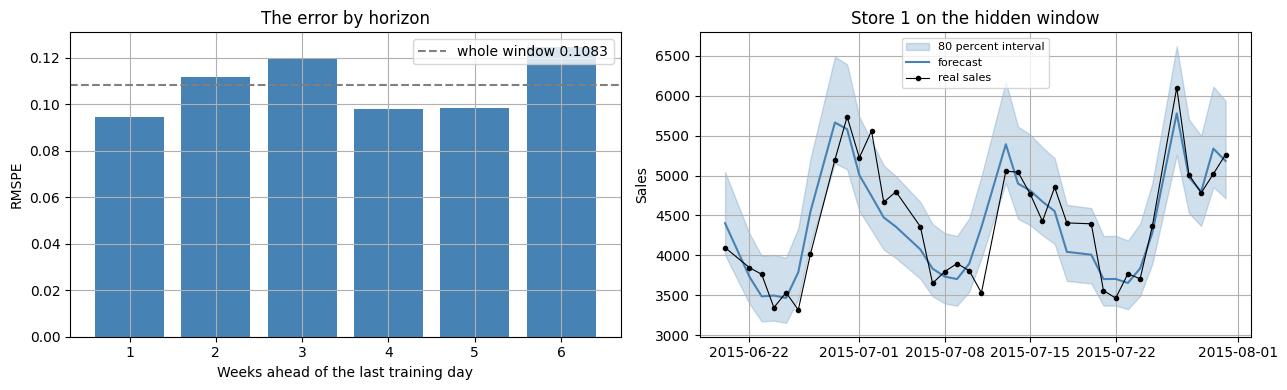

Time spent, in seconds:
  base model                      87
  RMSPE-weighted objective       108
  3 and 6 segments               164
  patience and reuse             169
  third seed                      43


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(by_horizon["week_ahead"], by_horizon["rmspe"], color="steelblue")
axes[0].axhline(score, color="gray", linestyle="--", label=f"whole window {score:.4f}")
axes[0].set_xlabel("Weeks ahead of the last training day")
axes[0].set_ylabel("RMSPE")
axes[0].set_title("The error by horizon")
axes[0].legend()

sample = (scored.filter(pl.col("Store") == 1).sort("Date"))
axes[1].fill_between(sample["Date"], sample["low"], sample["high"], color="steelblue", alpha=0.25,
                     label="80 percent interval")
axes[1].plot(sample["Date"], sample["prediction"], color="steelblue", label="forecast")
axes[1].plot(sample["Date"], sample["Sales"], color="black", marker=".", linewidth=0.8, label="real sales")
axes[1].set_title("Store 1 on the hidden window")
axes[1].set_ylabel("Sales")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Time spent, in seconds:")
for name, seconds in timings.items():
    print(f"  {name:<28} {seconds:5.0f}")

## Key findings

1. **The business reading:** a median miss of 400 units on a 6,400-unit
   day, no lean to either side, and no growth of the error with the
   horizon, because the model uses only what is known in advance.
2. **The recipe holds under the questions.** The logarithm beats the exact
   RMSPE objective, four segments is the right number, the closed-day family
   is a method and not a trick, and the 0.002 of notebook 08 was the early
   stopping patience, now exact.
3. **Three seeds are worth a thousandth**, at three times the file. The
   option exists; the default stays one.
4. **The interval is honest and a little narrow:** 75 percent held for a
   promised 80, for the same reason the calibration failed - the spread
   moves between six-week blocks.
5. **The production questions have answers in the code:** a guard for rows
   without their plan, `evaluate` with thresholds for monitoring, a
   challenger rule for retraining, and a model card that says what was
   trained on what.

Every measurement here is one seed on one window, the screening protocol
of notebook 07. None of them changes the model; all of them say why it is
the way it is.